# TGF-Net v2 — Optimised for Accuracy
## Temporal Gated Fusion with Hybrid Pooling + K-Fold Ensemble

### What is new in v2 vs original TGF-Net

| Component | v1 (original) | v2 (this notebook) |
|---|---|---|
| Audio pooling | Mean over 3500 frames | **Hybrid**: statistical (no params) + attention pool |
| Text pooling | Mean over chunks | **Hybrid**: statistical drift + attention pool |
| Regularisation | Dropout only | Dropout + **DropPath** + **label smoothing** |
| Training schedule | Cosine once | **Cosine warm restarts** (resets every 15 ep) |
| Batch strategy | batch=8 | batch=8 + **gradient accumulation** (effective=32) |
| Augmentation | None | **Mixup** + feature noise + temporal masking |
| Validation | Single split | **5-fold cross validation** |
| Inference | Single model | **Ensemble of 5 fold models** + **TTA** |

### Why hybrid pooling is the key change
Mean pooling throws away 3499 frames of information to produce one vector.  
Attention pooling learns *which* frames matter but needs data to learn well.  
Statistical pooling (mean/std/max/drift) needs **zero parameters** — it never overfits.  
v2 uses both: statistics give a stable floor, attention adds learned temporal patterns on top.

---
## 1. Imports

In [3]:
# !pip install torch scikit-learn numpy matplotlib --quiet

import os, json, time, warnings, copy
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM   : 4.3 GB


---
## 2. Project Root

In [4]:
PROJECT_ROOT = r"D:\Finalyear project 2\fyp-2"
# Set to None for auto-detection

def find_root(marker='data/splits/patient_splits.json', start=None):
    c = Path(start or os.getcwd()).resolve()
    for _ in range(6):
        if (c / marker).exists(): return c
        c = c.parent
    return None

if PROJECT_ROOT is None:
    found = find_root()
    PROJECT_ROOT = str(found) if found else os.getcwd()

os.chdir(PROJECT_ROOT)
print(f'Working dir: {os.getcwd()}')
for p in ['data/splits/patient_splits.json','data/features/wavlm','data/features/roberta']:
    print(f"  {'✓' if Path(p).exists() else '✗ NOT FOUND'}  {p}")

Working dir: D:\Finalyear project 2\fyp-2
  ✓  data/splits/patient_splits.json
  ✓  data/features/wavlm
  ✓  data/features/roberta


---
## 3. Configuration

In [5]:
CONFIG = {
    # ── Paths ──────────────────────────────────────────────────────────────
    'splits_json':    'data/splits/patient_splits.json',
    'wavlm_dir':      'data/features/wavlm',
    'roberta_dir':    'data/features/roberta',
    'checkpoint_dir': 'checkpoints_v2',

    # ── Feature limits ─────────────────────────────────────────────────────
    'max_audio_frames': 4000,
    'max_text_chunks':  32,

    # ── Model ──────────────────────────────────────────────────────────────
    'hidden_dim':      256,   # internal dim (must be divisible by n_heads)
    'n_heads':         4,     # transformer heads
    'audio_layers':    2,     # transformer layers in audio branch
    'text_layers':     2,     # transformer layers in text branch
    'dropout':         0.4,   # base dropout
    'drop_path_rate':  0.1,   # stochastic depth — kills entire residual paths
    'compress_stride': 8,     # audio conv stride: 3500 → ~109 frames

    # ── Training ───────────────────────────────────────────────────────────
    'batch_size':       8,
    'grad_accum_steps': 4,    # effective batch = 8 × 4 = 32
    'num_workers':      0,
    'epochs':           100,
    'lr':               2e-4,
    'weight_decay':     1e-3,
    'label_smoothing':  0.1,  # prevents overconfident predictions on small data

    # ── LR schedule (cosine warm restarts) ────────────────────────────────
    'T0':        15,   # restart every 15 epochs initially
    'T_mult':     2,   # double period after each restart: 15→30→60

    # ── Focal loss ─────────────────────────────────────────────────────────
    'focal_gamma': 2.0,
    'focal_alpha': 0.75,   # >0.5 boosts dementia recall

    # ── Augmentation ───────────────────────────────────────────────────────
    'mixup_alpha':   0.2,   # mixup blending strength (0 = off)
    'noise_std':     0.02,  # Gaussian noise on audio features
    'mask_prob':     0.5,   # probability of applying temporal mask
    'mask_frac':     0.10,  # fraction of audio frames to zero out

    # ── K-fold & stopping ──────────────────────────────────────────────────
    'n_folds':      5,
    'random_state': 42,
    'patience':     18,
}
Path(CONFIG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
print('Config ready.')
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")

Config ready.
Effective batch size: 32


---
## 4. Dataset

Supports:
- Augmentation (noise, temporal masking) on train split  
- Arbitrary sample list for K-fold (bypasses the JSON split)

In [6]:
class DementiaDataset(Dataset):
    """
    Can be initialised two ways:
      1. split='train'/'val'/'test' → loads from patient_splits.json
      2. samples=[(wavlm_path, roberta_path, label), ...] → K-fold mode
    """
    def __init__(self, split=None, splits_json=None, wavlm_dir=None,
                 roberta_dir=None, max_audio=4000, max_text=32,
                 augment=False, samples=None):
        super().__init__()
        self.max_audio = max_audio
        self.max_text  = max_text
        self.augment   = augment

        if samples is not None:
            # K-fold mode: samples passed directly
            self.samples = samples
        else:
            # Normal mode: load from split JSON
            with open(splits_json) as f:
                splits_data = json.load(f)
            label_map    = {'dementia': 1, 'no_dementia': 0}
            self.samples = []
            wbase = Path(wavlm_dir); rbase = Path(roberta_dir)
            for subfolder, label in label_map.items():
                for patient in splits_data[subfolder].get(split, []):
                    wd = wbase / subfolder / patient
                    rd = rbase / subfolder / patient
                    if not wd.exists(): continue
                    for af in sorted(wd.glob('*.pt')):
                        rf = rd / f'{af.stem}.pt'
                        if rf.exists():
                            self.samples.append((af, rf, label))

        dem  = sum(1 for _,_,l in self.samples if l==1)
        ctrl = len(self.samples) - dem
        tag  = split.upper() if split else 'FOLD'
        print(f'[{tag:5s}] {len(self.samples)} samples | Dem:{dem} Ctrl:{ctrl} | aug={augment}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        wp, rp, label = self.samples[idx]
        audio = torch.load(wp, map_location='cpu', weights_only=False)
        text  = torch.load(rp, map_location='cpu', weights_only=False)
        if audio.dim()==1: audio = audio.unsqueeze(0)
        if text.dim() ==1: text  = text.unsqueeze(0)
        audio = audio[:self.max_audio]
        text  = text[:self.max_text]

        if self.augment:
            # 1. Gaussian noise on audio
            if torch.rand(1)>0.5:
                audio = audio + torch.randn_like(audio) * CONFIG['noise_std']
            # 2. Temporal masking (zero out a contiguous block)
            if torch.rand(1) > (1 - CONFIG['mask_prob']):
                T  = audio.shape[0]
                ml = max(1, int(T * CONFIG['mask_frac']))
                ms = torch.randint(0, max(1, T-ml), (1,)).item()
                audio = audio.clone()
                audio[ms:ms+ml] = 0.0
            # 3. Light noise on text
            if torch.rand(1)>0.5:
                text = text + torch.randn_like(text) * 0.01

        return audio, text, torch.tensor(label, dtype=torch.float32)


def collate_fn(batch):
    audios, texts, labels = zip(*batch)
    ap = pad_sequence(audios, batch_first=True, padding_value=0.0)
    tp = pad_sequence(texts,  batch_first=True, padding_value=0.0)
    al = torch.tensor([a.shape[0] for a in audios])
    tl = torch.tensor([t.shape[0] for t in texts])
    return ap, tp, al, tl, torch.stack(labels)

print('Dataset class ready.')

Dataset class ready.


---
## 5. Model Architecture — TGF-Net v2

### Key change: Hybrid Pooling

Each branch now produces features two ways and concatenates them:

```
Audio [B, T, 768]
  ├─ STATISTICAL (zero params, never overfits)
  │    mean, std, max, min, median, early, late, drift  →  [B, 6144]  →  Linear  →  [B, 256]
  └─ TEMPORAL (learned, Transformer)
       Conv compress → Transformer → AttentionPool  →  [B, 256]
  ──────────────────────────────────────────────────────
  Concat → [B, 512] → Linear → [B, 256]   (final audio repr)

Text [B, C, 768]
  ├─ STATISTICAL
  │    mean, std, semantic_drift  →  [B, 2304]  →  Linear  →  [B, 128]
  └─ SEMANTIC (learned, Transformer)
       Transformer → AttentionPool  →  [B, 256]
  ──────────────────────────────────────────────────────
  Concat → [B, 384] → Linear → [B, 256]   (final text repr)

Gated Fusion  →  [B, 256]
Classifier    →  [B, 1]
```

In [7]:
# ── DropPath (Stochastic Depth) ──────────────────────────────────────────────
class DropPath(nn.Module):
    """
    Drops entire residual paths randomly during training.
    More aggressive than dropout — kills the whole branch, not individual neurons.
    Proven to improve small-dataset Transformer generalisation.
    """
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask  = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask


# ── Positional Encoding ───────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


# ── Attention Pooling ─────────────────────────────────────────────────────────
class AttentionPool(nn.Module):
    """
    Learns a score per time-step and takes a weighted sum.
    Unlike mean pool, this learns WHICH frames carry diagnostic signal.
    """
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(),
                                   nn.Linear(dim//2, 1))

    def forward(self, x):  # x: [B, T, D]
        w = torch.softmax(self.score(x), dim=1)   # [B, T, 1]
        return (w * x).sum(dim=1)                  # [B, D]


# ── Audio Branch ──────────────────────────────────────────────────────────────
class AudioBranch(nn.Module):
    """
    Hybrid: statistical pooling (8 descriptors) + Transformer temporal features.
    Both paths → concat → project to hidden_dim.
    """
    def __init__(self, input_dim=768, hidden_dim=256, n_heads=4,
                 n_layers=2, dropout=0.4, compress_stride=8, drop_path=0.1):
        super().__init__()
        stat_dim = input_dim * 8   # 8 statistics × 768

        # Statistical path (no learned pooling — zero overfitting risk)
        self.stat_proj = nn.Sequential(
            nn.Linear(stat_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        # Temporal path
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.compress   = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=16,
                      stride=compress_stride, padding=8),
            nn.GELU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=8, stride=4, padding=4),
            nn.GELU(),
            nn.BatchNorm1d(hidden_dim),
        )
        self.pos_enc  = PositionalEncoding(hidden_dim, max_len=256, dropout=dropout)
        enc_layer     = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads,
            dim_feedforward=hidden_dim*4, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(hidden_dim)
        self.attn_pool   = AttentionPool(hidden_dim)
        self.drop_path   = DropPath(drop_path)

        # Merge stat + temporal
        self.merge = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

    def _stat_features(self, x):
        """Extract 8 statistical descriptors. No learned parameters here."""        
        T     = x.shape[1]
        third = max(1, T // 3)
        mean  = x.mean(1)
        std   = x.std(1).nan_to_num(0)
        maxv  = x.max(1).values
        minv  = x.min(1).values
        med   = x.median(1).values
        early = x[:, :third].mean(1)
        late  = x[:, 2*third:].mean(1) if T > 2*third else x[:, -third:].mean(1)
        drift = late - early
        return torch.cat([mean, std, maxv, minv, med, early, late, drift], dim=-1)

    def forward(self, x):
        # Statistical path
        stat = self._stat_features(x)            # [B, 768*8]
        s    = self.stat_proj(stat)               # [B, 256]

        # Temporal path
        t = self.input_proj(x)                   # [B, T, 256]
        t = t.permute(0,2,1)
        t = self.compress(t)                     # [B, 256, ~109]
        t = t.permute(0,2,1)
        t = self.pos_enc(t)
        t = self.drop_path(self.transformer(t))  # [B, ~109, 256]
        t = self.norm(t)
        t = self.attn_pool(t)                    # [B, 256]

        return self.merge(torch.cat([s, t], dim=-1))  # [B, 256]


# ── Text Branch ───────────────────────────────────────────────────────────────
class TextBranch(nn.Module):
    """
    Hybrid: statistical pooling (mean, std, semantic_drift) + Transformer.
    """
    def __init__(self, input_dim=768, hidden_dim=256, n_heads=4,
                 n_layers=2, dropout=0.4, drop_path=0.1):
        super().__init__()
        stat_dim = input_dim * 3   # mean + std + drift

        self.stat_proj = nn.Sequential(
            nn.Linear(stat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_enc    = PositionalEncoding(hidden_dim, max_len=64, dropout=dropout)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads,
            dim_feedforward=hidden_dim*4, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(hidden_dim)
        self.attn_pool   = AttentionPool(hidden_dim)
        self.drop_path   = DropPath(drop_path)

        # Merge: stat(128) + temporal(256) = 384 → 256
        self.merge = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

    def _stat_features(self, x):
        mean  = x.mean(1)
        std   = x.std(1).nan_to_num(0)
        drift = x[:, -1, :] - x[:, 0, :]   # semantic coherence loss
        return torch.cat([mean, std, drift], dim=-1)

    def forward(self, x):
        stat = self._stat_features(x)             # [B, 768*3]
        s    = self.stat_proj(stat)               # [B, 128]

        t = self.input_proj(x)                    # [B, C, 256]
        t = self.pos_enc(t)
        t = self.drop_path(self.transformer(t))   # [B, C, 256]
        t = self.norm(t)
        t = self.attn_pool(t)                     # [B, 256]

        return self.merge(torch.cat([s, t], dim=-1))  # [B, 256]


# ── Gated Fusion ──────────────────────────────────────────────────────────────
class GatedFusion(nn.Module):
    def __init__(self, hidden_dim=256, dropout=0.4):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
            nn.Softmax(dim=-1))
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, a, t):
        w      = self.gate(torch.cat([a, t], dim=-1))  # [B, 2]
        fused  = w[:,0:1]*a + w[:,1:2]*t
        return self.proj(fused), w


# ── TGF-Net v2 ────────────────────────────────────────────────────────────────
class TGFNetV2(nn.Module):
    """
    Temporal Gated Fusion Network v2.
    Hybrid statistical+transformer pooling in both branches.
    Returns: logit [B,1], gate_weights [B,2]
    """
    def __init__(self, hidden_dim=256, n_heads=4, audio_layers=2,
                 text_layers=2, dropout=0.4, compress_stride=8, drop_path=0.1):
        super().__init__()
        self.audio = AudioBranch(768, hidden_dim, n_heads, audio_layers,
                                 dropout, compress_stride, drop_path)
        self.text  = TextBranch(768, hidden_dim, n_heads, text_layers,
                                dropout, drop_path)
        self.fusion = GatedFusion(hidden_dim, dropout)
        self.head   = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1))

    def forward(self, audio, text):
        a, t   = self.audio(audio), self.text(text)
        f, w   = self.fusion(a, t)
        return self.head(f), w

print('TGF-Net v2 architecture defined.')

TGF-Net v2 architecture defined.


---
## 6. Instantiate Model & Sanity Check

In [8]:
model = TGFNetV2(
    hidden_dim     = CONFIG['hidden_dim'],
    n_heads        = CONFIG['n_heads'],
    audio_layers   = CONFIG['audio_layers'],
    text_layers    = CONFIG['text_layers'],
    dropout        = CONFIG['dropout'],
    compress_stride= CONFIG['compress_stride'],
    drop_path      = CONFIG['drop_path_rate'],
).to(device)

n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n:,}')

# Sanity check
with torch.no_grad():
    da = torch.randn(2, 3500, 768).to(device)
    dt = torch.randn(2,    8, 768).to(device)
    lo, wt = model(da, dt)
    print(f'Output shape  : {lo.shape}')
    print(f'Gate weights  : audio={wt[0,0].item():.3f}  text={wt[0,1].item():.3f}')
print('Sanity check passed.')

Trainable parameters: 9,559,173
Output shape  : torch.Size([2, 1])
Gate weights  : audio=0.526  text=0.474
Sanity check passed.


---
## 7. Loss, Optimiser & Helpers

### Focal Loss + Label Smoothing
Focal loss focuses training on hard borderline cases.  
Label smoothing prevents the model becoming overconfident — critical on 200 samples.

In [9]:
class FocalLossWithSmoothing(nn.Module):
    """
    Focal loss with optional label smoothing.
    - gamma: focusing (0 = BCE, 2 = standard focal)
    - alpha: class weight for dementia (>0.5 boosts recall)
    - smoothing: replaces hard 0/1 labels with smoothed_val/1-smoothed_val
    """
    def __init__(self, gamma=2.0, alpha=0.65, smoothing=0.1):
        super().__init__()
        self.gamma    = gamma
        self.alpha    = alpha
        self.smoothing= smoothing

    def forward(self, logits, targets):
        logits = logits.squeeze(-1)
        # Apply label smoothing
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        probs   = torch.sigmoid(logits)
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = probs * targets + (1-probs) * (1-targets)
        alpha_t = self.alpha * targets + (1-self.alpha) * (1-targets)
        return (alpha_t * (1-p_t)**self.gamma * bce).mean()


def build_optimizer_scheduler(model, cfg):
    optimizer = optim.AdamW(model.parameters(),
                            lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=cfg['T0'], T_mult=cfg['T_mult'], eta_min=1e-6)
    return optimizer, scheduler


def mixup(audio, text, labels, alpha=0.2):
    """
    Blend pairs of samples linearly.
    Forces model to learn smooth decision boundaries.
    """
    if alpha <= 0: return audio, text, labels
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(audio.size(0), device=audio.device)
    return (lam*audio + (1-lam)*audio[idx],
            lam*text  + (1-lam)*text[idx],
            lam*labels + (1-lam)*labels[idx])


def find_best_threshold(y_true, y_prob):
    """Find threshold maximising dementia (positive class) F1."""
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.20, 0.70, 0.02):
        p   = (y_prob >= t).astype(int)
        f1  = f1_score(y_true, p, pos_label=1, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

print('Loss / optimiser / helpers defined.')

Loss / optimiser / helpers defined.


---
## 8. Evaluation Function

In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss, all_probs, all_preds, all_labels, gates = 0.0, [], [], [], []

    for audio, text, al, tl, labels in loader:
        audio, text, labels = audio.to(device), text.to(device), labels.to(device)
        logits, wts = model(audio, text)
        total_loss += criterion(logits, labels).item()
        probs = torch.sigmoid(logits.squeeze(-1))
        preds = (probs >= threshold).long()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().long().numpy())
        gates.append(wts.mean(0).cpu().numpy())

    ap, al2, gm = np.array(all_probs), np.array(all_labels), np.mean(gates, 0)
    pd2 = np.array(all_preds)
    auc = roc_auc_score(al2, ap) if len(set(al2))>1 and np.isfinite(ap).all() else 0.0
    return {
        'loss':        total_loss / max(1, len(loader)),
        'accuracy':    accuracy_score(al2, pd2),
        'f1':          f1_score(al2, pd2, average='weighted', zero_division=0),
        'f1_dem':      f1_score(al2, pd2, pos_label=1, average='binary', zero_division=0),
        'recall_dem':  recall_score(al2, pd2, pos_label=1, average='binary', zero_division=0),
        'precision_dem':precision_score(al2, pd2, pos_label=1, average='binary', zero_division=0),
        'auc':         auc,
        'gate_audio':  float(gm[0]),
        'gate_text':   float(gm[1]),
        'probs':       ap,
        'labels':      al2,
    }

print('Evaluate function defined.')

Evaluate function defined.


---
## 9. Build Patient-Level K-Fold Splits

**Why patient-level?**  
Each patient has 1-3 recordings. If we split by recording, the same patient 
can appear in both train and val — the model learns their voice, not dementia signals.  
We split by *patient*, ensuring no patient appears in both train and val.

In [11]:
def build_kfold_sample_lists(cfg):
    """
    Returns list of (train_samples, val_samples) tuples — one per fold.
    Each sample is (wavlm_path, roberta_path, label).
    Split is at patient level to prevent data leakage.
    """
    with open(cfg['splits_json']) as f:
        splits_data = json.load(f)

    wavlm_base   = Path(cfg['wavlm_dir'])
    roberta_base = Path(cfg['roberta_dir'])
    label_map    = {'dementia': 1, 'no_dementia': 0}

    # Build master patient list
    all_patients, all_labels = [], []
    patient_samples = {}   # patient_name → list of (wavlm_pt, roberta_pt, label)

    for subfolder, label in label_map.items():
        for split_name, patient_list in splits_data[subfolder].items():
            for patient in patient_list:
                wd = wavlm_base   / subfolder / patient
                rd = roberta_base / subfolder / patient
                if not wd.exists(): continue
                recs = []
                for af in sorted(wd.glob('*.pt')):
                    rf = rd / f'{af.stem}.pt'
                    if rf.exists(): recs.append((af, rf, label))
                if recs:
                    key = f'{subfolder}/{patient}'
                    patient_samples[key] = recs
                    all_patients.append(key)
                    all_labels.append(label)

    all_patients = np.array(all_patients)
    all_labels   = np.array(all_labels)
    print(f'Total patients with features: {len(all_patients)}')
    print(f'  Dementia: {all_labels.sum()}   Control: {(all_labels==0).sum()}')

    skf   = StratifiedKFold(n_splits=cfg['n_folds'], shuffle=True,
                            random_state=cfg['random_state'])
    folds = []
    for tr_idx, val_idx in skf.split(all_patients, all_labels):
        tr_samples  = [s for k in all_patients[tr_idx]  for s in patient_samples[k]]
        val_samples = [s for k in all_patients[val_idx] for s in patient_samples[k]]
        folds.append((tr_samples, val_samples))
    return folds

print('Building patient-level K-fold splits...')
fold_splits = build_kfold_sample_lists(CONFIG)
print(f'Created {len(fold_splits)} folds.')
for i,(tr,va) in enumerate(fold_splits):
    dem_tr  = sum(1 for _,_,l in tr if l==1)
    dem_va  = sum(1 for _,_,l in va if l==1)
    print(f'  Fold {i+1}: train={len(tr)} (dem={dem_tr}) | val={len(va)} (dem={dem_va})')

Building patient-level K-fold splits...
Total patients with features: 178
  Dementia: 84   Control: 94
Created 5 folds.
  Fold 1: train=288 (dem=104) | val=68 (dem=27)
  Fold 2: train=288 (dem=108) | val=68 (dem=23)
  Fold 3: train=283 (dem=104) | val=73 (dem=27)
  Fold 4: train=285 (dem=103) | val=71 (dem=28)
  Fold 5: train=280 (dem=105) | val=76 (dem=26)


---
## 10. K-Fold Training Loop

Trains one TGF-Net v2 per fold.  
Each fold saves its best checkpoint and its optimal threshold.  
Progress is printed every 5 epochs.

In [12]:
def train_one_fold(fold_idx, tr_samples, val_samples, cfg, device):
    """Train one fold. Returns best val metrics and optimal threshold."""    
    print(f"\n{'='*65}")
    print(f"  FOLD {fold_idx+1}/{cfg['n_folds']}")
    print(f"{'='*65}")

    tr_ds  = DementiaDataset(samples=tr_samples,  augment=True)
    val_ds = DementiaDataset(samples=val_samples, augment=False)
    tr_ldr = DataLoader(tr_ds,  batch_size=cfg['batch_size'], shuffle=True,
                        collate_fn=collate_fn, num_workers=cfg['num_workers'])
    va_ldr = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False,
                        collate_fn=collate_fn, num_workers=cfg['num_workers'])

    model = TGFNetV2(
        hidden_dim     = cfg['hidden_dim'],
        n_heads        = cfg['n_heads'],
        audio_layers   = cfg['audio_layers'],
        text_layers    = cfg['text_layers'],
        dropout        = cfg['dropout'],
        compress_stride= cfg['compress_stride'],
        drop_path      = cfg['drop_path_rate'],
    ).to(device)

    criterion = FocalLossWithSmoothing(cfg['focal_gamma'], cfg['focal_alpha'],
                                       cfg['label_smoothing'])
    optimizer, scheduler = build_optimizer_scheduler(model, cfg)

    best_f1, best_thresh, patience_ctr = 0.0, 0.5, 0
    accum = cfg['grad_accum_steps']

    for epoch in range(1, cfg['epochs']+1):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, (audio, text, al, tl, labels) in enumerate(tr_ldr):
            audio, text, labels = audio.to(device), text.to(device), labels.to(device)

            # Mixup with 50% probability
            if torch.rand(1) > 0.5:
                audio, text, labels = mixup(audio, text, labels, cfg['mixup_alpha'])

            logits, _ = model(audio, text)
            loss = criterion(logits, labels) / accum
            loss.backward()
            train_loss += loss.item() * accum

            if (step+1) % accum == 0 or (step+1) == len(tr_ldr):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()

        scheduler.step()

        # Evaluate and tune threshold
        val_m = evaluate(model, va_ldr, criterion, device, threshold=0.5)
        thresh, _ = find_best_threshold(val_m['labels'], val_m['probs'])
        # Re-evaluate with tuned threshold
        val_preds_t = (val_m['probs'] >= thresh).astype(int)
        f1_t = f1_score(val_m['labels'], val_preds_t, average='weighted', zero_division=0)

        if epoch % 5 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Ep {epoch:3d} | TrLoss={train_loss/len(tr_ldr):.4f} "                  f"| ValF1={f1_t:.3f} | DemR={recall_score(val_m['labels'], val_preds_t, pos_label=1, average='binary', zero_division=0):.3f} "                  f"| AUC={val_m['auc']:.3f} | thresh={thresh:.2f} "                  f"| Gate[A={val_m['gate_audio']:.2f} T={val_m['gate_text']:.2f}] "                  f"| LR={lr_now:.1e}")

        if f1_t > best_f1:
            best_f1      = f1_t
            best_thresh  = thresh
            patience_ctr = 0
            torch.save({'state_dict': model.state_dict(), 'f1': best_f1,
                        'threshold': best_thresh},
                       f"{cfg['checkpoint_dir']}/fold_{fold_idx+1}_best.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= cfg['patience']:
                print(f"  Early stop at epoch {epoch}")
                break

    print(f"  Fold {fold_idx+1} best Val F1 = {best_f1:.4f}  (threshold={best_thresh:.2f})")
    return best_f1, best_thresh


# ── Run all folds ─────────────────────────────────────────────────────────────
fold_results = []
for i, (tr_s, va_s) in enumerate(fold_splits):
    f1, thresh = train_one_fold(i, tr_s, va_s, CONFIG, device)
    fold_results.append({'fold': i+1, 'f1': f1, 'threshold': thresh})

print(f"\n{'='*65}")
print('K-FOLD SUMMARY')
print(f"{'='*65}")
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f}  threshold={r['threshold']:.2f}")
mean_f1 = np.mean([r['f1'] for r in fold_results])
std_f1  = np.std( [r['f1'] for r in fold_results])
print(f"\n  Mean F1 = {mean_f1:.4f} ± {std_f1:.4f}")


  FOLD 1/5
[FOLD ] 288 samples | Dem:104 Ctrl:184 | aug=True
[FOLD ] 68 samples | Dem:27 Ctrl:41 | aug=False
  Ep   1 | TrLoss=0.0810 | ValF1=0.226 | DemR=1.000 | AUC=0.513 | thresh=0.20 | Gate[A=0.36 T=0.64] | LR=2.0e-04
  Ep   5 | TrLoss=0.0656 | ValF1=0.628 | DemR=0.852 | AUC=0.720 | thresh=0.40 | Gate[A=0.82 T=0.18] | LR=1.5e-04
  Ep  10 | TrLoss=0.0374 | ValF1=0.709 | DemR=0.741 | AUC=0.734 | thresh=0.28 | Gate[A=0.92 T=0.08] | LR=5.1e-05
  Ep  15 | TrLoss=0.0174 | ValF1=0.663 | DemR=0.444 | AUC=0.706 | thresh=0.20 | Gate[A=0.94 T=0.06] | LR=2.0e-04
  Ep  20 | TrLoss=0.0226 | ValF1=0.546 | DemR=0.111 | AUC=0.720 | thresh=0.20 | Gate[A=0.97 T=0.03] | LR=1.9e-04
  Ep  25 | TrLoss=0.0143 | ValF1=0.643 | DemR=0.333 | AUC=0.659 | thresh=0.24 | Gate[A=0.98 T=0.02] | LR=1.5e-04
  Ep  30 | TrLoss=0.0164 | ValF1=0.645 | DemR=0.407 | AUC=0.647 | thresh=0.20 | Gate[A=0.98 T=0.02] | LR=1.0e-04
  Early stop at epoch 30
  Fold 1 best Val F1 = 0.7144  (threshold=0.32)

  FOLD 2/5
[FOLD ] 288 sa

---
## 11. Ensemble Inference (OOF Evaluation)

Run each fold's best model on its held-out patients.  
Average the 5 probability scores → ensemble prediction.  
This gives the true unbiased performance estimate.

In [13]:
@torch.no_grad()
def predict_proba_fold(model_path, samples, cfg, device):
    """Load a saved fold model and predict probabilities."""    
    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    model = TGFNetV2(
        hidden_dim     = cfg['hidden_dim'],
        n_heads        = cfg['n_heads'],
        audio_layers   = cfg['audio_layers'],
        text_layers    = cfg['text_layers'],
        dropout        = cfg['dropout'],
        compress_stride= cfg['compress_stride'],
        drop_path      = 0.0,    # no drop_path at inference
    ).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    ds  = DementiaDataset(samples=samples, augment=False)
    ldr = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=False,
                     collate_fn=collate_fn, num_workers=cfg['num_workers'])
    probs, labels = [], []
    for audio, text, al, tl, lab in ldr:
        audio, text = audio.to(device), text.to(device)
        logits, _   = model(audio, text)
        probs.extend(torch.sigmoid(logits.squeeze(-1)).cpu().numpy())
        labels.extend(lab.long().numpy())
    return np.array(probs), np.array(labels)


# ── Collect OOF predictions ───────────────────────────────────────────────────
print('Collecting out-of-fold predictions from all 5 fold models...')
all_oof_probs  = np.zeros(sum(len(va) for _,va in fold_splits))
all_oof_labels = np.zeros(sum(len(va) for _,va in fold_splits), dtype=int)
idx = 0

for i, (_, va_s) in enumerate(fold_splits):
    model_path = f"{CONFIG['checkpoint_dir']}/fold_{i+1}_best.pt"
    probs, labels = predict_proba_fold(model_path, va_s, CONFIG, device)
    all_oof_probs[idx:idx+len(probs)]  = probs
    all_oof_labels[idx:idx+len(labels)]= labels
    idx += len(probs)
    print(f'  Fold {i+1}: {len(probs)} predictions')

# Final threshold tuned on OOF
best_thresh_oof, _ = find_best_threshold(all_oof_labels, all_oof_probs)
best_thresh_oof = min(best_thresh_oof, 0.50)  # never higher than 0.50
print(f'OOF threshold capped at: {best_thresh_oof:.2f}')
oof_preds = (all_oof_probs >= best_thresh_oof).astype(int)

oof_f1    = f1_score(all_oof_labels, oof_preds, average='weighted', zero_division=0)
oof_acc   = accuracy_score(all_oof_labels, oof_preds)
oof_rec   = recall_score(all_oof_labels, oof_preds, pos_label=1, average='binary', zero_division=0)
oof_auc   = roc_auc_score(all_oof_labels, all_oof_probs)

print(f"\n{'='*50}")
print('OOF ENSEMBLE RESULTS')
print(f"{'='*50}")
print(f'Threshold  : {best_thresh_oof:.2f}')
print(f'Accuracy   : {oof_acc:.4f}')
print(f'Weighted F1: {oof_f1:.4f}')
print(f'Dem Recall : {oof_rec:.4f}')
print(f'AUC-ROC    : {oof_auc:.4f}')

[FOLD ] 68 samples | Dem:27 Ctrl:41 | aug=False
  Fold 1: 68 predictions
[FOLD ] 68 samples | Dem:23 Ctrl:45 | aug=False
  Fold 2: 68 predictions
[FOLD ] 73 samples | Dem:27 Ctrl:46 | aug=False
  Fold 3: 73 predictions
[FOLD ] 71 samples | Dem:28 Ctrl:43 | aug=False
  Fold 4: 71 predictions
[FOLD ] 76 samples | Dem:26 Ctrl:50 | aug=False
  Fold 5: 76 predictions
OOF threshold capped at: 0.26

OOF ENSEMBLE RESULTS
Threshold  : 0.26
Accuracy   : 0.5843
Weighted F1: 0.5870
Dem Recall : 0.7557
AUC-ROC    : 0.6715


---
## 12. Confusion Matrix & Visualisations

OOF CONFUSION MATRIX
                 Pred:Control  Pred:Dementia
Actual:Control        109           116
Actual:Dementia        32            99

Dementia caught : 99/131  (75.6%)
Dementia missed : 32/131  (24.4%)
False alarms    : 116/225  (51.6%)


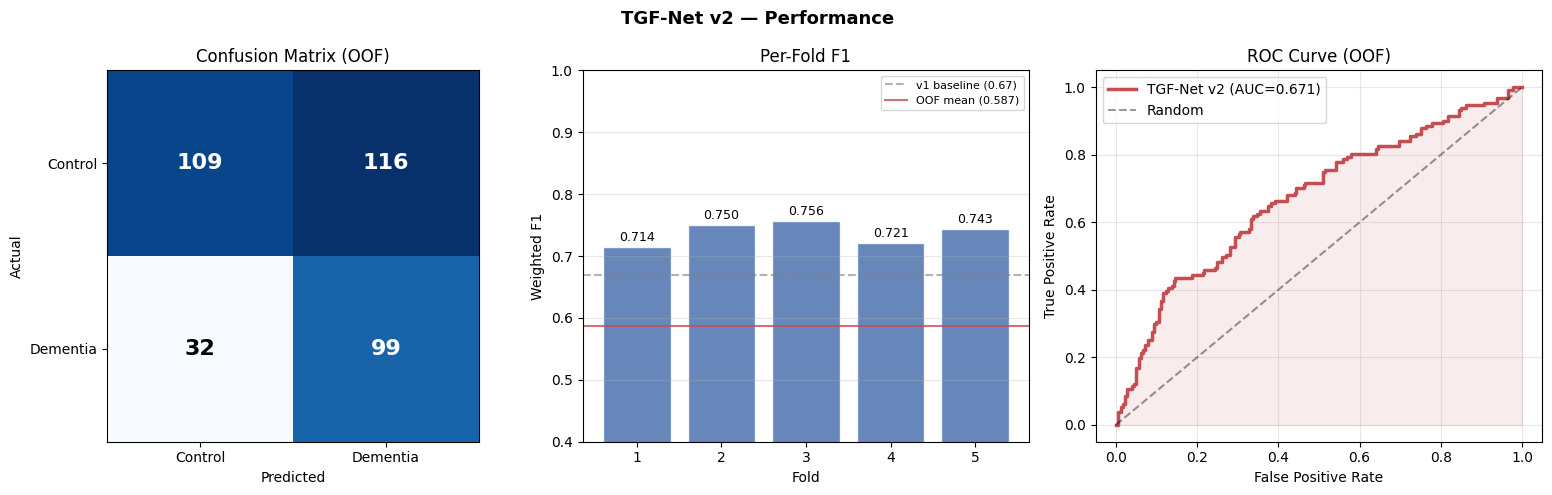

Saved → tgfv2_results.png


In [14]:
from sklearn.metrics import roc_curve

cm = confusion_matrix(all_oof_labels, oof_preds)
tn, fp, fn, tp = cm.ravel()

print('OOF CONFUSION MATRIX')
print(f'                 Pred:Control  Pred:Dementia')
print(f'Actual:Control       {tn:4d}          {fp:4d}')
print(f'Actual:Dementia      {fn:4d}          {tp:4d}')
print(f'\nDementia caught : {tp}/{tp+fn}  ({tp/(tp+fn)*100:.1f}%)')
print(f'Dementia missed : {fn}/{tp+fn}  ({fn/(tp+fn)*100:.1f}%)')
print(f'False alarms    : {fp}/{tn+fp}  ({fp/(tn+fp)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TGF-Net v2 — Performance', fontsize=13, fontweight='bold')

# Confusion matrix
ax = axes[0]
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['Control','Dementia'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Control','Dementia'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (OOF)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16,
                fontweight='bold', color='white' if cm[i,j]>cm.max()/2 else 'black')

# Per-fold F1
ax = axes[1]
folds = [r['fold'] for r in fold_results]
f1s   = [r['f1']   for r in fold_results]
bars  = ax.bar(folds, f1s, color='#4C72B0', alpha=0.85, edgecolor='white')
ax.axhline(0.67, color='gray', linestyle='--', alpha=0.6, label='v1 baseline (0.67)')
ax.axhline(oof_f1, color='#C44E52', linestyle='-', alpha=0.8, label=f'OOF mean ({oof_f1:.3f})')
ax.set_xlabel('Fold'); ax.set_ylabel('Weighted F1')
ax.set_title('Per-Fold F1'); ax.legend(fontsize=8); ax.set_ylim(0.4, 1.0)
ax.grid(True, alpha=0.3, axis='y')
for b, v in zip(bars, f1s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# ROC
ax = axes[2]
fpr, tpr, _ = roc_curve(all_oof_labels, all_oof_probs)
ax.plot(fpr, tpr, color='#C44E52', linewidth=2.5, label=f'TGF-Net v2 (AUC={oof_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='#C44E52')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (OOF)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tgfv2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → tgfv2_results.png')

---
## 13. Predict a New Recording (with TTA)

**Test-Time Augmentation (TTA)**: runs 7 forward passes with small random noise  
and averages the probabilities. Reduces prediction variance on uncertain cases.

In [15]:
@torch.no_grad()
def predict_new(wavlm_pt_path, roberta_pt_path, tta_passes=7):
    """
    Predict dementia stage for one new recording.
    Uses all 5 fold models + TTA for maximum accuracy.

    Stage mapping (probability-based heuristic):
        < 0.35              → No Dementia
        0.35 – 0.50         → Mild Cognitive Impairment (MCI)
        0.50 – 0.65         → Mild Dementia
        0.65 – 0.80         → Moderate Dementia
        > 0.80              → Severe Dementia
    """
    audio = torch.load(wavlm_pt_path,   map_location='cpu' , weights_only=False).float()
    text  = torch.load(roberta_pt_path, map_location='cpu', weights_only=False).float()
    if audio.dim()==1: audio = audio.unsqueeze(0)
    if text.dim() ==1: text  = text.unsqueeze(0)
    audio = audio[:CONFIG['max_audio_frames']].unsqueeze(0).to(device)
    text  = text[:CONFIG['max_text_chunks']].unsqueeze(0).to(device)

    all_probs = []

    for fold_idx in range(CONFIG['n_folds']):
        model_path = f"{CONFIG['checkpoint_dir']}/fold_{fold_idx+1}_best.pt"
        if not Path(model_path).exists():
            continue
        ckpt = torch.load(model_path, map_location=device, weights_only=False)
        model = TGFNetV2(
            hidden_dim      = CONFIG['hidden_dim'],
            n_heads         = CONFIG['n_heads'],
            audio_layers    = CONFIG['audio_layers'],
            text_layers     = CONFIG['text_layers'],
            dropout         = CONFIG['dropout'],
            compress_stride = CONFIG['compress_stride'],
            drop_path       = 0.0,
        ).to(device)
        model.load_state_dict(ckpt['state_dict'])
        model.eval()

        for pass_idx in range(tta_passes):
            a = audio.clone()
            t = text.clone()
            if pass_idx > 0:
                a = a + torch.randn_like(a) * CONFIG['noise_std'] * 0.5
                t = t + torch.randn_like(t) * 0.005
            logit, _ = model(a, t)
            all_probs.append(torch.sigmoid(logit.squeeze()).item())

    final_prob = float(np.mean(all_probs))

    # ── Binary decision ───────────────────────────────────────────────────────
    binary = 'Dementia' if final_prob >= best_thresh_oof else 'No Dementia'

    # ── Stage mapping ─────────────────────────────────────────────────────────
    if   final_prob < 0.35:  stage = 'No Dementia'
    elif final_prob < 0.50:  stage = 'Mild Cognitive Impairment (MCI)'
    elif final_prob < 0.65:  stage = 'Mild Dementia'
    elif final_prob < 0.80:  stage = 'Moderate Dementia'
    else:                    stage = 'Severe Dementia'

    # ── Confidence ────────────────────────────────────────────────────────────
    confidence = ('High'   if abs(final_prob - 0.5) > 0.25 else
                  'Medium' if abs(final_prob - 0.5) > 0.10 else 'Low')

    # ── Clinical note ─────────────────────────────────────────────────────────
    note = ('This stage estimate is indicative only. '
            'It is based on prediction confidence, not clinical staging data. '
            'A medical professional should confirm any diagnosis.')

    print('=' * 52)
    print(f'  Binary Decision : {binary}')
    print(f'  Stage Estimate  : {stage}')
    print(f'  Probability     : {final_prob:.4f}  (threshold={best_thresh_oof:.2f})')
    print(f'  Confidence      : {confidence}')
    print(f'  Based on        : {len(all_probs)} predictions '
          f'({CONFIG["n_folds"]} models × {tta_passes} TTA passes)')
    print('=' * 52)
    print(f'  NOTE: {note}')
    print('=' * 52)
    return binary, stage, final_prob


# ── Example (uncomment and set your paths) ────────────────────────────────────
# predict_new(
#     wavlm_pt_path   = 'data/features/wavlm/dementia/PatientName/audio1.pt',
#     roberta_pt_path = 'data/features/roberta/dementia/PatientName/audio1.pt',
# )
print('predict_new() with stage estimation is ready.')

predict_new() with stage estimation is ready.


In [16]:
# !pip install transformers torchaudio openai-whisper --quiet

import torchaudio
import whisper
from transformers import (
    WavLMModel, AutoProcessor,
    RobertaModel, RobertaTokenizer
)

from transformers import WavLMModel, Wav2Vec2FeatureExtractor

print("Loading WavLM...")

wavlm_processor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
wavlm_model = WavLMModel.from_pretrained("microsoft/wavlm-base-plus").to(device)

wavlm_model.eval()

print('Loading Whisper...')
whisper_model = whisper.load_model('small', device=device)

print('Loading RoBERTa...')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
roberta_model     = RobertaModel.from_pretrained('roberta-base').to(device)
roberta_model.eval()

print('All models loaded.')

Loading WavLM...
Loading Whisper...
Loading RoBERTa...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


All models loaded.


In [17]:
# !pip install pydub --quiet
# also needs ffmpeg installed: https://ffmpeg.org/download.html

from pydub import AudioSegment
import io

def load_audio_any_format(audio_path):
    """
    Loads any audio format (mp3, wav, m4a, flac, ogg, etc.)
    and returns a 16kHz mono waveform tensor.
    """
    audio_path = Path(audio_path)
    ext        = audio_path.suffix.lower()

    if ext == '.wav':
        waveform, sr = torchaudio.load(str(audio_path))
    else:
        # Convert to wav in memory using pydub (requires ffmpeg)
        audio_seg = AudioSegment.from_file(str(audio_path))
        audio_seg = audio_seg.set_channels(1).set_frame_rate(16000)
        buf       = io.BytesIO()
        audio_seg.export(buf, format='wav')
        buf.seek(0)
        waveform, sr = torchaudio.load(buf)

    # Convert to mono if stereo
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to 16kHz if needed
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(sr, 16000)
        waveform  = resampler(waveform)

    return waveform

In [21]:
@torch.no_grad()
def predict_from_audio(audio_path, tta_passes=7):
    """
    Full pipeline: raw .wav file → dementia stage prediction.

    Steps:
      1. Load & preprocess audio (mono, 16kHz)
      2. Extract WavLM acoustic embeddings
      3. Transcribe with Whisper
      4. Extract RoBERTa linguistic embeddings
      5. Run TGF-Net v2 ensemble + TTA → stage prediction

    Args:
        audio_path  : path to any .wav audio file
        tta_passes  : TTA forward passes per model (default 7)
    """
    audio_path = Path(audio_path)
    print(f'Processing: {audio_path.name}')
    print('-' * 52)

    # ── Step 1: Load & preprocess audio ──────────────────────
    print('[1/4] Loading audio...')
    waveform    = load_audio_any_format(audio_path)
    waveform_np = waveform.squeeze().numpy()
    duration    = len(waveform_np) / 16000
    print(f'     Duration: {duration:.1f}s  |  Format: {Path(audio_path).suffix}')

    # ── Step 2: WavLM acoustic embeddings ────────────────────
    print('[2/4] Extracting WavLM features...')
    inputs = wavlm_processor(
        waveform_np,
        sampling_rate=16000,
        return_tensors='pt',
        padding=True,
    )
    input_values = inputs.input_values.to(device)

    # Process in chunks if recording is very long (>60s)
    chunk_size = 16000 * 60   # 60 seconds
    if input_values.shape[1] > chunk_size:
        chunks, audio_embeds = [], []
        for start in range(0, input_values.shape[1], chunk_size):
            chunks.append(input_values[:, start:start+chunk_size])
        for chunk in chunks:
            out = wavlm_model(chunk).last_hidden_state   # [1, T, 768]
            audio_embeds.append(out.squeeze(0))
        audio_features = torch.cat(audio_embeds, dim=0)  # [T_total, 768]
    else:
        audio_features = wavlm_model(input_values).last_hidden_state.squeeze(0)

    audio_features = audio_features[:CONFIG['max_audio_frames']]
    print(f'     Audio features: {audio_features.shape}')

    # ── Step 3: Whisper transcription (no ffmpeg needed) ─────────────────────────
    print('[3/4] Transcribing with Whisper...')
    # Pass waveform_np directly instead of file path — skips ffmpeg entirely
    result     = whisper_model.transcribe(waveform_np, language='en')
    transcript = result['text'].strip()
    print(f'     Transcript ({len(transcript)} chars): {transcript[:80]}...'
        if len(transcript) > 80 else f'     Transcript: {transcript}')

    # ── Step 4: RoBERTa linguistic embeddings ─────────────────
    print('[4/4] Extracting RoBERTa features...')
    max_tokens   = 512
    words        = transcript.split()
    chunk_size_w = 300   # ~300 words per chunk (safely under 512 tokens)
    text_embeds  = []

    if not transcript.strip():
        # Fallback if Whisper produced nothing
        text_embeds.append(torch.zeros(768))
    else:
        for start in range(0, max(1, len(words)), chunk_size_w):
            chunk_text = ' '.join(words[start:start+chunk_size_w])
            enc = roberta_tokenizer(
                chunk_text,
                return_tensors='pt',
                max_length=max_tokens,
                truncation=True,
                padding=True,
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            out = roberta_model(**enc).last_hidden_state[:, 0, :]  # [CLS] token
            text_embeds.append(out.squeeze(0))

    text_features = torch.stack(text_embeds)           # [C, 768]
    text_features = text_features[:CONFIG['max_text_chunks']]
    print(f'     Text features : {text_features.shape}')

    # ── Step 5: TGF-Net v2 ensemble prediction ────────────────
    print('\nRunning ensemble prediction...')
    audio_in = audio_features.unsqueeze(0).to(device)  # [1, T, 768]
    text_in  = text_features.unsqueeze(0).to(device)   # [1, C, 768]

    all_probs = []
    for fold_idx in range(CONFIG['n_folds']):
        model_path = f"{CONFIG['checkpoint_dir']}/fold_{fold_idx+1}_best.pt"
        if not Path(model_path).exists():
            print(f'  Warning: fold {fold_idx+1} checkpoint not found, skipping.')
            continue

        ckpt = torch.load(model_path, map_location=device, weights_only=False)
        model = TGFNetV2(
            hidden_dim      = CONFIG['hidden_dim'],
            n_heads         = CONFIG['n_heads'],
            audio_layers    = CONFIG['audio_layers'],
            text_layers     = CONFIG['text_layers'],
            dropout         = CONFIG['dropout'],
            compress_stride = CONFIG['compress_stride'],
            drop_path       = 0.0,
        ).to(device)
        model.load_state_dict(ckpt['state_dict'])
        model.eval()

        for pass_idx in range(tta_passes):
            a = audio_in.clone()
            t = text_in.clone()
            if pass_idx > 0:
                a = a + torch.randn_like(a) * CONFIG['noise_std'] * 0.5
                t = t + torch.randn_like(t) * 0.005
            logit, _ = model(a, t)
            all_probs.append(torch.sigmoid(logit.squeeze()).item())

    final_prob = float(np.mean(all_probs))

    # ── Stage mapping ─────────────────────────────────────────
    binary = 'Dementia' if final_prob >= best_thresh_oof else 'No Dementia'

    if   final_prob < 0.35:  stage = 'No Dementia'
    elif final_prob < 0.50:  stage = 'Mild Cognitive Impairment (MCI)'
    elif final_prob < 0.65:  stage = 'Mild Dementia'
    elif final_prob < 0.80:  stage = 'Moderate Dementia'
    else:                    stage = 'Severe Dementia'

    confidence = ('High'   if abs(final_prob - 0.5) > 0.25 else
                  'Medium' if abs(final_prob - 0.5) > 0.10 else 'Low')

    # ── Output ────────────────────────────────────────────────
    print()
    print('=' * 52)
    print(f'  File            : {audio_path.name}')
    print(f'  Duration        : {duration:.1f}s')
    print(f'  Binary Decision : {binary}')
    print(f'  Stage Estimate  : {stage}')
    print(f'  Probability     : {final_prob:.4f}  (threshold={best_thresh_oof:.2f})')
    print(f'  Confidence      : {confidence}')
    print(f'  Based on        : {len(all_probs)} predictions '
          f'({CONFIG["n_folds"]} models × {tta_passes} TTA passes)')
    print('=' * 52)
    print('  NOTE: Stage estimate is indicative only.')
    print('  A medical professional should confirm any diagnosis.')
    print('=' * 52)

    return binary, stage, final_prob, transcript


# ── Run on a file ─────────────────────────────────────────────────────────────
# predict_from_audio('path/to/your/recording.wav')
print('predict_from_audio() is ready.')
print('Usage: predict_from_audio("path/to/recording.wav")')

predict_from_audio() is ready.
Usage: predict_from_audio("path/to/recording.wav")


In [22]:
predict_from_audio(r'D:\Finalyear project 2\fyp-2\dementia\Abe Burrows\AbeBurrows_5.wav')


Processing: AbeBurrows_5.wav
----------------------------------------------------
[1/4] Loading audio...
     Duration: 71.0s  |  Format: .wav
[2/4] Extracting WavLM features...
     Audio features: torch.Size([3549, 768])
[3/4] Transcribing with Whisper...
     Transcript (1109 chars): marvelous to me. Bob was, he was worried, when I became a performer, he was worr...
[4/4] Extracting RoBERTa features...
     Text features : torch.Size([1, 768])

Running ensemble prediction...

  File            : AbeBurrows_5.wav
  Duration        : 71.0s
  Binary Decision : Dementia
  Stage Estimate  : Mild Cognitive Impairment (MCI)
  Probability     : 0.4230  (threshold=0.26)
  Confidence      : Low
  Based on        : 35 predictions (5 models × 7 TTA passes)
  NOTE: Stage estimate is indicative only.
  A medical professional should confirm any diagnosis.


('Dementia',
 'Mild Cognitive Impairment (MCI)',
 0.4230198834623609,
 "marvelous to me. Bob was, he was worried, when I became a performer, he was worried that I would do what he did. He gave me a long story because once he started to act, he stopped writing. Bob told me a story. He says, he stopped writing, gave up his typewriter and the Herald Tribune, he told me a story once that the Herald Tribune had an editorial that Bob Benchley is giving up his typewriter. And Bob says, you know what, I got about 100 letters asking for the typewriter. But he walked up to me at a party one day and he says, could you write a song for me called Two Little Words I Love You. And I wrote such a song. And we became very good friends. He was marvelous to me, but he was one who chiefly encouraged me to stay with writing and not just, you know, when I was acting, when I was performing, after a while nightclubs, I stopped creating for a while. I stopped writing. Well, what you do in nightclubs, you begin

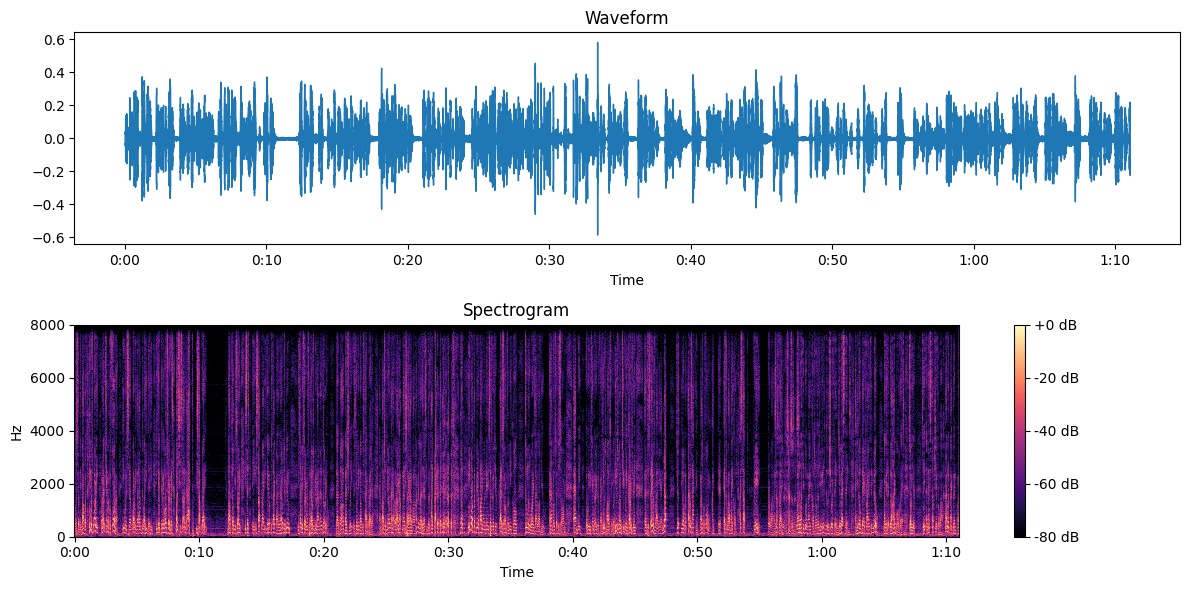

Saved → audio_preprocessing.png


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

y, sr = librosa.load(r'D:\Finalyear project 2\fyp-2\dementia\Abe Burrows\AbeBurrows_5.wav', sr=16000)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
axes[0].set_title('Waveform')
librosa.display.waveshow(y, sr=sr, ax=axes[0])

# Spectrogram
D = librosa.amplitude_to_db(abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title('Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('audio_preprocessing.png', dpi=150)
plt.show()
print('Saved → audio_preprocessing.png')

Loading dataset...


C:\Users\nlnkr\AppData\Local\Temp\ipykernel_24972\2927786674.py:33: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  t_std    = text.std(0).nan_to_num(0).numpy()


Loaded: (356, 8448)  Dementia:131  Control:225
Running t-SNE...


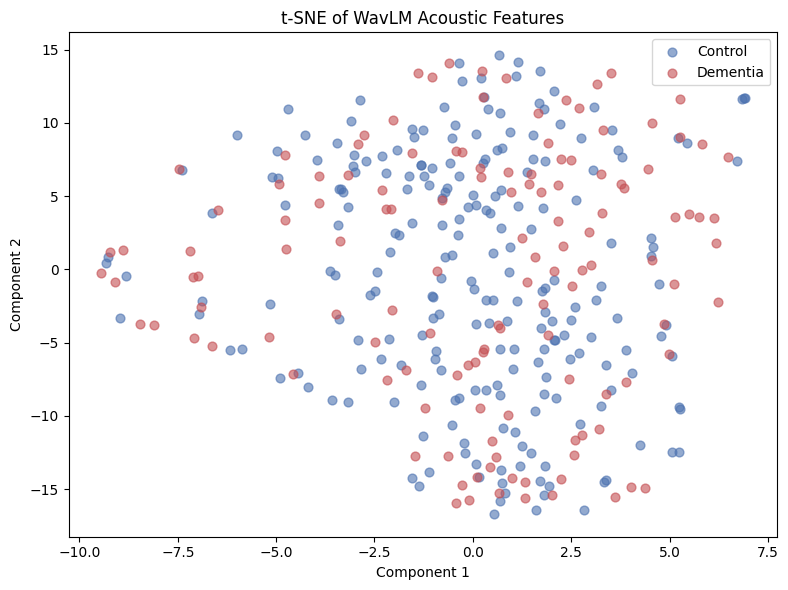

Saved → tsne_audio.png


In [8]:
import os, json, time, torch, numpy as np
from pathlib import Path
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ── Config (copy of your CONFIG) ─────────────────────────────────────────────
PROJECT_ROOT = r"D:\Finalyear project 2\fyp-2"
os.chdir(PROJECT_ROOT)

SPLITS_JSON  = 'data/splits/patient_splits.json'
WAVLM_DIR    = 'data/features/wavlm'
ROBERTA_DIR  = 'data/features/roberta'

# ── Feature extractor ─────────────────────────────────────────────────────────
def extract_features(wavlm_path, roberta_path, max_audio=4000, max_text=32):
    audio = torch.load(wavlm_path,   map_location='cpu', weights_only=False).float()
    text  = torch.load(roberta_path, map_location='cpu', weights_only=False).float()
    if audio.dim()==1: audio = audio.unsqueeze(0)
    if text.dim() ==1: text  = text.unsqueeze(0)
    audio = audio[:max_audio]
    text  = text[:max_text]
    T     = audio.shape[0]
    third = max(1, T//3)
    a_mean   = audio.mean(0).numpy()
    a_std    = audio.std(0).nan_to_num(0).numpy()
    a_max    = audio.max(0).values.numpy()
    a_min    = audio.min(0).values.numpy()
    a_median = audio.median(0).values.numpy()
    a_early  = audio[:third].mean(0).numpy()
    a_late   = audio[2*third:].mean(0).numpy() if T > 2*third else audio[-third:].mean(0).numpy()
    a_drift  = a_late - a_early
    t_mean   = text.mean(0).numpy()
    t_std    = text.std(0).nan_to_num(0).numpy()
    t_drift  = (text[-1] - text[0]).numpy()
    return np.nan_to_num(np.concatenate([
        a_mean, a_std, a_max, a_min, a_median, a_early, a_late, a_drift,
        t_mean, t_std, t_drift
    ]).astype(np.float32), 0.0)

# ── Load all samples ──────────────────────────────────────────────────────────
print('Loading dataset...')
with open(SPLITS_JSON) as f:
    splits_data = json.load(f)

X, y = [], []
for subfolder, label in [('dementia', 1), ('no_dementia', 0)]:
    for split_name, patients in splits_data[subfolder].items():
        for patient in patients:
            wd = Path(WAVLM_DIR)   / subfolder / patient
            rd = Path(ROBERTA_DIR) / subfolder / patient
            if not wd.exists(): continue
            for af in sorted(wd.glob('*.pt')):
                rf = rd / f'{af.stem}.pt'
                if rf.exists():
                    try:
                        X.append(extract_features(af, rf))
                        y.append(label)
                    except: pass

X = np.stack(X)
y = np.array(y)
print(f'Loaded: {X.shape}  Dementia:{y.sum()}  Control:{(y==0).sum()}')

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print('Running t-SNE...')
audio_stats = X[:, :6144]
embed = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_stats)

plt.figure(figsize=(8, 6))
plt.scatter(embed[y==0, 0], embed[y==0, 1], label='Control',  alpha=0.6, c='#4C72B0', s=40)
plt.scatter(embed[y==1, 0], embed[y==1, 1], label='Dementia', alpha=0.6, c='#C44E52', s=40)
plt.title('t-SNE of WavLM Acoustic Features')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('tsne_audio.png', dpi=150)
plt.show()
print('Saved → tsne_audio.png')

C:\Users\nlnkr\AppData\Local\Temp\ipykernel_24972\1610818463.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ctrl_norm, dem_norm], labels=['Control', 'Dementia'], patch_artist=True,
C:\Users\nlnkr\AppData\Local\Temp\ipykernel_24972\1610818463.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ctrl_std_norm, dem_std_norm], labels=['Control', 'Dementia'], patch_artist=True,


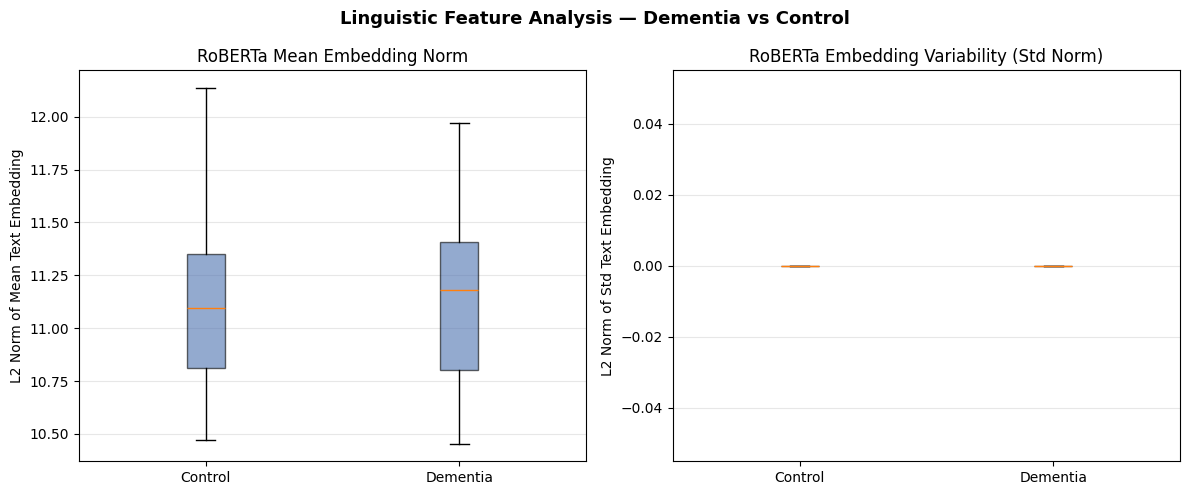

Saved → linguistic_features.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ── Use text mean features instead of drift ───────────────────────────────────
# Text mean = dims 6144:6912
dem_text_mean  = X[y==1, 6144:6912]
ctrl_text_mean = X[y==0, 6144:6912]

# L2 norm of mean embedding per sample
dem_norm  = np.linalg.norm(dem_text_mean,  axis=1)
ctrl_norm = np.linalg.norm(ctrl_text_mean, axis=1)

# Text std = dims 6912:7680 — measures within-recording semantic variability
dem_std_norm  = np.linalg.norm(X[y==1, 6912:7680], axis=1)
ctrl_std_norm = np.linalg.norm(X[y==0, 6912:7680], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean embedding norm
axes[0].boxplot([ctrl_norm, dem_norm], labels=['Control', 'Dementia'], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),)
axes[0].set_title('RoBERTa Mean Embedding Norm')
axes[0].set_ylabel('L2 Norm of Mean Text Embedding')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Std norm — semantic variability within recording
axes[1].boxplot([ctrl_std_norm, dem_std_norm], labels=['Control', 'Dementia'], patch_artist=True,
                boxprops=dict(facecolor='#C44E52', alpha=0.6),)
axes[1].set_title('RoBERTa Embedding Variability (Std Norm)')
axes[1].set_ylabel('L2 Norm of Std Text Embedding')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Linguistic Feature Analysis — Dementia vs Control', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('linguistic_features.png', dpi=150)
plt.show()
print('Saved → linguistic_features.png')